# Joint traditional–network modeling-sample audit

This notebook audits the combined modeling sample produced by `scripts/18_build_network_modeling_sample.py`. It does not repeat the raw network-feature analysis from the preceding network notebook.

It checks:

1. exact preservation of the original modeling sample;
2. independent reproduction, ranges, and missingness of the six retained network ranks;
3. training-only cross-sectional correlations between network and traditional predictors; and
4. the relative univariate target associations of both feature groups.

The correlation and target diagnostics use only the training split. They describe overlap and association, not incremental predictive value; that question is answered by out-of-sample model comparison in Script 19.

## 1. Setup and inputs

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import seaborn as sns


project_root = Path.cwd().resolve()

while not (project_root / 'config' / 'paths.yaml').is_file():
    if project_root.parent == project_root:
        raise FileNotFoundError('Could not locate the project root.')
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.modeling.feature_sets import RANKED_NETWORK_FEATURES
from src.utils.configuration import get_paths_config
from src.visualization.style import (
    COLOR_PALETTE,
    apply_matplotlib_layout,
    set_matplotlib_style,
)


key = ['report_period', 'information_date', 'permno']
target = 'future_max_drawdown_63d'
market_features = [
    'market_cap_usd',
    'average_daily_dollar_volume_63d',
    'return_21d',
    'momentum_252_21d',
    'volatility_63d',
    'downside_volatility_63d',
    'market_beta_252d',
    'maximum_drawdown_252d',
    'negative_return_share_63d',
]
ownership_features = [
    'institutional_holder_count',
    'total_reported_value_usd',
    'reported_ownership_hhi',
    'top_five_reported_ownership_share',
    'mean_owner_portfolio_weight',
    'maximum_owner_portfolio_weight',
    'manager_holder_share',
    'institutional_holder_count_change_percent',
    'total_reported_value_change_percent',
    'reported_ownership_hhi_change',
    'top_five_reported_ownership_share_change',
]
traditional_features = market_features + ownership_features
raw_network_features = [
    'owner_similarity_score',
    'value_weighted_owner_degree_centrality',
    'value_weighted_owner_neighbor_similarity',
    'owner_community_count',
    'owner_community_hhi',
    'largest_owner_community_share',
    'owner_similarity_score_change',
    'owner_community_hhi_change',
]
network_features = [f'{feature}_rank' for feature in raw_network_features]
retained_network_features = list(RANKED_NETWORK_FEATURES)
static_network_features = [
    feature
    for feature in retained_network_features
    if not feature.endswith('_change_rank')
]
change_network_features = [
    feature
    for feature in retained_network_features
    if feature.endswith('_change_rank')
]

traditional_labels = {
    'market_cap_usd': 'Market cap',
    'average_daily_dollar_volume_63d': 'Dollar volume',
    'return_21d': 'Return (21d)',
    'momentum_252_21d': 'Momentum',
    'volatility_63d': 'Volatility',
    'downside_volatility_63d': 'Downside volatility',
    'market_beta_252d': 'Market beta',
    'maximum_drawdown_252d': 'Past drawdown',
    'negative_return_share_63d': 'Negative-return share',
    'institutional_holder_count': 'Holder count',
    'total_reported_value_usd': 'Reported value',
    'reported_ownership_hhi': 'Ownership HHI',
    'top_five_reported_ownership_share': 'Top-five ownership share',
    'mean_owner_portfolio_weight': 'Mean owner weight',
    'maximum_owner_portfolio_weight': 'Maximum owner weight',
    'manager_holder_share': 'Manager-holder share',
    'institutional_holder_count_change_percent': 'Holder-count change',
    'total_reported_value_change_percent': 'Reported-value change',
    'reported_ownership_hhi_change': 'Ownership-HHI change',
    'top_five_reported_ownership_share_change': 'Top-five-share change',
}
network_labels = {
    'owner_similarity_score_rank': 'Owner similarity',
    'value_weighted_owner_degree_centrality_rank': 'Owner degree centrality',
    'value_weighted_owner_neighbor_similarity_rank': 'Owner-neighbor similarity',
    'owner_community_count_rank': 'Owner community count',
    'owner_community_hhi_rank': 'Owner community HHI',
    'largest_owner_community_share_rank': 'Largest community share',
    'owner_similarity_score_change_rank': 'Owner similarity change',
    'owner_community_hhi_change_rank': 'Owner community HHI change',
}

paths = get_paths_config()
modeling_directory = paths.processed / 'modeling'
base_path = modeling_directory / 'modeling_sample.parquet'
network_path = modeling_directory / 'network_modeling_sample.parquet'
raw_network_path = paths.interim / 'networks' / 'stock_network_features.parquet'

for description, path in {
    'original modeling sample': base_path,
    'network modeling sample': network_path,
    'raw network features': raw_network_path,
}.items():
    if not path.is_file():
        raise FileNotFoundError(f'{description} not found: {path}')

base_sample = pd.read_parquet(base_path)
network_sample = pd.read_parquet(network_path)
raw_network = pd.read_parquet(raw_network_path)
training = base_sample.loc[base_sample['sample_split'].eq('train')].copy()

set_matplotlib_style()

print(f'Original-sample observations: {len(base_sample):,}')
print(f'Network observations: {len(network_sample):,}')
print(f'Training observations: {len(training):,}')
print(f'Retained network predictors: {len(retained_network_features)}')

Original-sample observations: 184,018
Network observations: 184,018
Training observations: 123,791
Retained network predictors: 6


## 2. Exact preservation of the original sample

Script 18 should append the six retained network-feature ranks without changing any original modeling-sample value, row, order, target, or chronological split.

In [2]:
expected_columns = [*base_sample.columns, *retained_network_features]
columns_match = list(network_sample.columns) == expected_columns
baseline_values_match = network_sample[base_sample.columns].equals(base_sample)
duplicate_rows = int(network_sample.duplicated(key).sum())

if not columns_match:
    raise RuntimeError('The combined sample has unexpected columns.')
if not baseline_values_match:
    raise RuntimeError('An original modeling-sample value or row changed.')
if duplicate_rows:
    raise RuntimeError('The combined sample contains duplicate stock-quarters.')

split_summary = (
    network_sample.groupby('sample_split', as_index=False)
    .agg(
        first_quarter=('report_period', 'min'),
        last_quarter=('report_period', 'max'),
        quarters=('report_period', 'nunique'),
        stock_quarters=('permno', 'size'),
        securities=('permno', 'nunique'),
    )
)
split_order = pd.CategoricalDtype(
    ['train', 'validation', 'test'],
    ordered=True,
)
split_summary['sample_split'] = split_summary['sample_split'].astype(split_order)
split_summary = split_summary.sort_values('sample_split')

display(
    split_summary.style.format(
        {
            'quarters': '{:,}',
            'stock_quarters': '{:,}',
            'securities': '{:,}',
        }
    )
)
print(f'Expected columns preserved: {columns_match}')
print(f'All original values preserved: {baseline_values_match}')
print(f'Duplicate stock-quarters: {duplicate_rows:,}')

,sample_split,first_quarter,last_quarter,quarters,stock_quarters,securities
1,train,2013-06-30 00:00:00,2021-09-30 00:00:00,34,"123,791","5,701"
2,validation,2022-03-31 00:00:00,2023-09-30 00:00:00,7,"29,716","4,733"
0,test,2024-03-31 00:00:00,2025-12-31 00:00:00,8,"30,511","4,255"


Expected columns preserved: True
All original values preserved: True
Duplicate stock-quarters: 0


## 3. Independent rank reproduction

The eight candidate network features are ranked over the complete security universe within each quarter before the modeling sample is selected. This cell independently reconstructs all eight candidates and compares the six retained features with every saved rank.

In [3]:
grouped = raw_network.groupby('report_period')[raw_network_features]
raw_ranks = grouped.rank(method='average')
raw_counts = grouped.transform('count')
expected_ranks = (raw_ranks - 1) / (raw_counts - 1)
expected_ranks = expected_ranks.where(raw_counts.ne(1), 0.5)
expected_ranks.columns = network_features
expected_ranks = pd.concat([raw_network[key], expected_ranks], axis='columns')
expected_for_sample = base_sample[key].merge(
    expected_ranks,
    on=key,
    how='left',
    validate='one_to_one',
)

actual_values = network_sample[retained_network_features].to_numpy()
expected_values = expected_for_sample[retained_network_features].to_numpy()
ranks_match = np.allclose(actual_values, expected_values, equal_nan=True)
maximum_difference = np.nanmax(np.abs(actual_values - expected_values))
nonmissing_ranks = network_sample[retained_network_features].stack()

if not ranks_match:
    raise RuntimeError('Saved network ranks do not match the raw features.')
if network_sample[static_network_features].isna().any().any():
    raise RuntimeError('Static network ranks contain missing values.')
if not nonmissing_ranks.between(0, 1).all():
    raise RuntimeError('A network rank falls outside [0, 1].')

rank_summary = pd.DataFrame(
    {
        'feature': retained_network_features,
        'minimum': network_sample[retained_network_features].min().to_numpy(),
        'median': network_sample[retained_network_features].median().to_numpy(),
        'maximum': network_sample[retained_network_features].max().to_numpy(),
        'missing_rows': network_sample[retained_network_features].isna().sum().to_numpy(),
        'missing_share': network_sample[retained_network_features].isna().mean().to_numpy(),
    }
)
display(
    rank_summary.style.format(
        {
            'minimum': '{:.3f}',
            'median': '{:.3f}',
            'maximum': '{:.3f}',
            'missing_rows': '{:,}',
            'missing_share': '{:.2%}',
        }
    )
)
print(f'All ranks independently reproduced: {ranks_match}')
print(f'Maximum absolute difference: {maximum_difference:.2e}')

candidate_sample = base_sample.merge(
    expected_ranks,
    on=key,
    how='left',
    sort=False,
    validate='one_to_one',
)
training = candidate_sample.loc[
    candidate_sample['sample_split'].eq('train')
].copy()

,feature,minimum,median,maximum,missing_rows,missing_share
0,owner_similarity_score_rank,0.004,0.503,1.000,0,0.00%
1,value_weighted_owner_degree_centrality_rank,0.000,0.516,1.000,0,0.00%
2,value_weighted_owner_neighbor_similarity_rank,0.000,0.514,1.000,0,0.00%
3,owner_community_hhi_rank,0.000,0.493,1.000,0,0.00%
4,owner_similarity_score_change_rank,0.000,0.498,1.000,"3,832",2.08%
5,owner_community_hhi_change_rank,0.000,0.502,1.000,"3,832",2.08%


All ranks independently reproduced: True
Maximum absolute difference: 0.00e+00


## 4. Cross-block predictor correlations

For this diagnostic, both traditional and network predictors are ranked within each training quarter. The resulting matrix measures cross-sectional overlap on a common scale and avoids correlations driven only by trends over time.

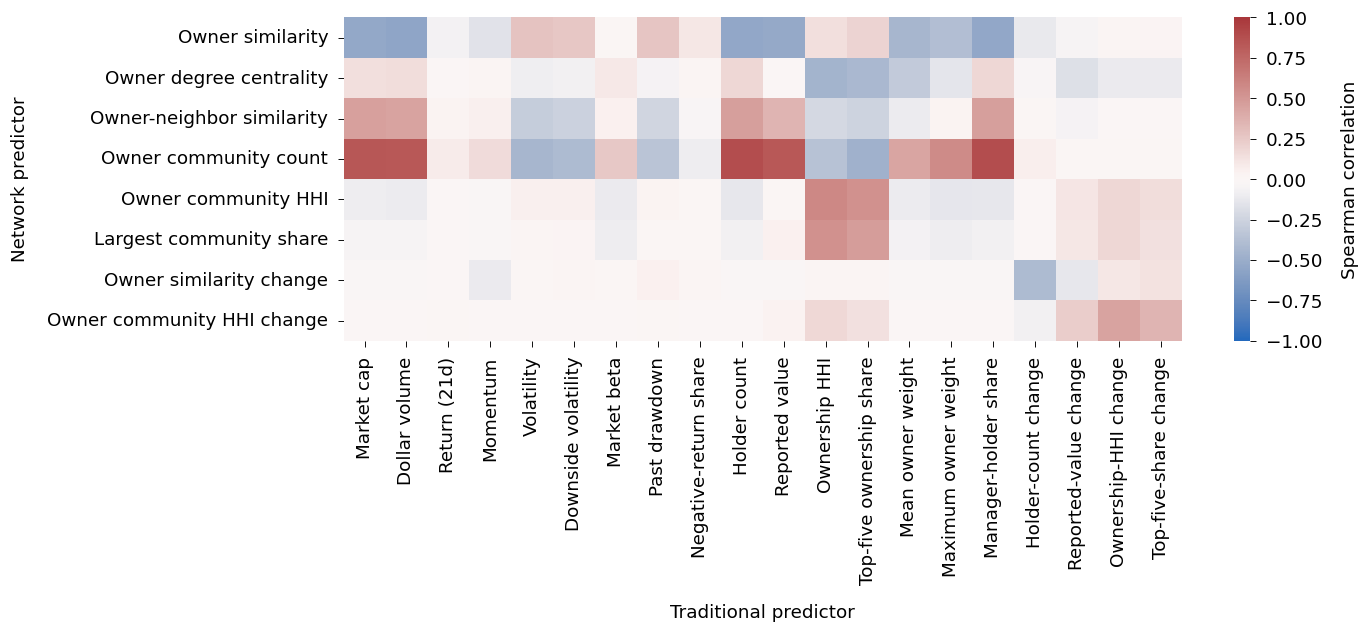

Cross-block pairs with |Spearman| >= 0.75: 5


,network_feature,traditional_feature,spearman,absolute_correlation
69,Owner community count,Holder count,0.890,0.890
75,Owner community count,Manager-holder share,0.890,0.890
60,Owner community count,Market cap,0.843,0.843
61,Owner community count,Dollar volume,0.833,0.833
70,Owner community count,Reported value,0.830,0.830
91,Owner community HHI,Ownership HHI,0.583,0.583
74,Owner community count,Maximum owner weight,0.567,0.567
1,Owner similarity,Dollar volume,-0.555,0.555
15,Owner similarity,Manager-holder share,-0.544,0.544
9,Owner similarity,Holder count,-0.544,0.544


In [4]:
joint_features = [*traditional_features, *network_features]
within_quarter_ranks = training.groupby('report_period')[joint_features].rank(
    method='average',
    pct=True,
)
joint_correlations = within_quarter_ranks.corr(method='spearman')
cross_block = joint_correlations.loc[network_features, traditional_features]
cross_block = cross_block.rename(index=network_labels, columns=traditional_labels)

figure, axis = plt.subplots(figsize=(13, 6))
sns.heatmap(
    cross_block,
    cmap='vlag',
    center=0,
    vmin=-1,
    vmax=1,
    cbar_kws={'label': 'Spearman correlation'},
    ax=axis,
)
axis.set_xlabel('Traditional predictor')
axis.set_ylabel('Network predictor')
apply_matplotlib_layout(figure)
figure.savefig(paths.figures / "04_03_network_traditional_correlations.pdf")
plt.show()

cross_block_pairs = (
    cross_block.stack()
    .rename('spearman')
    .reset_index()
    .rename(columns={'level_0': 'network_feature', 'level_1': 'traditional_feature'})
    .assign(absolute_correlation=lambda frame: frame['spearman'].abs())
    .sort_values('absolute_correlation', ascending=False)
)
strong_cross_block_pairs = cross_block_pairs.loc[
    cross_block_pairs['absolute_correlation'].ge(0.75)
]

print(
    'Cross-block pairs with |Spearman| >= 0.75: '
    f'{len(strong_cross_block_pairs)}'
)
display(
    cross_block_pairs.head(15).style.format(
        {'spearman': '{:.3f}', 'absolute_correlation': '{:.3f}'}
    )
)

## 5. Relative univariate target associations

Mean quarterly Spearman correlations place the traditional and network predictors on the same descriptive scale. They do not show whether a network predictor adds information after controlling for the traditional feature set.

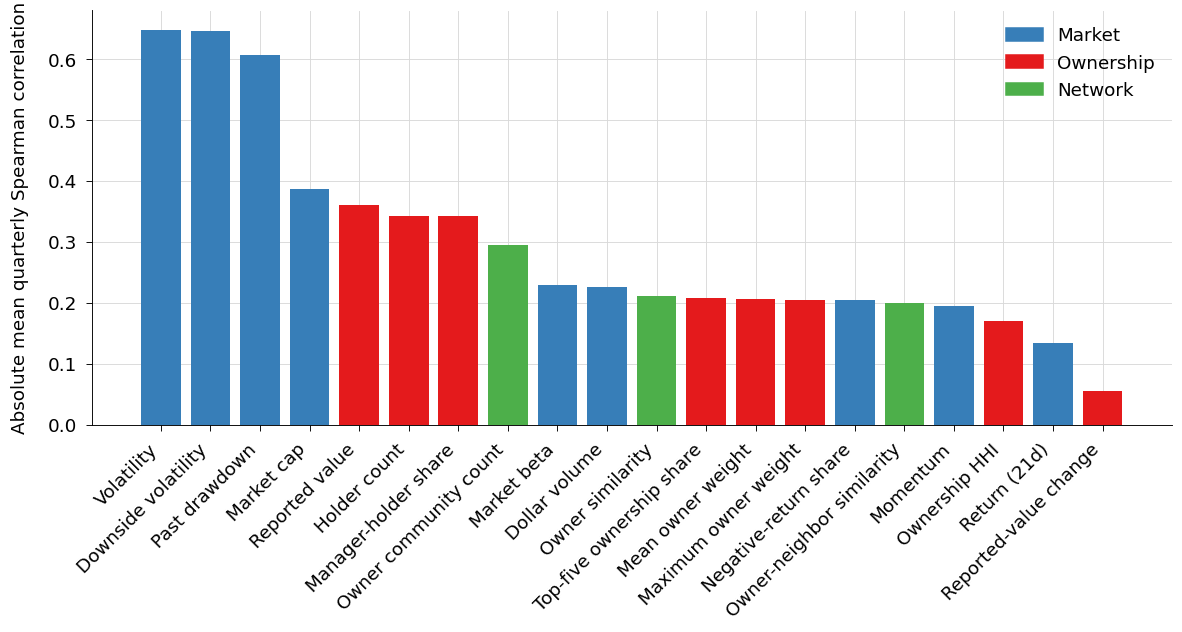

,feature_group,label,mean_quarterly_spearman,absolute_correlation
0,Market,Volatility,0.647,0.647
1,Market,Downside volatility,0.646,0.646
2,Market,Past drawdown,0.607,0.607
3,Market,Market cap,-0.386,0.386
4,Ownership,Reported value,-0.360,0.360
5,Ownership,Holder count,-0.343,0.343
6,Ownership,Manager-holder share,-0.343,0.343
7,Network,Owner community count,-0.295,0.295
8,Market,Market beta,0.230,0.230
9,Market,Dollar volume,-0.227,0.227


In [5]:
association_rows = []

for report_period, quarter in training.groupby("report_period", sort=True):
    correlations = (
        quarter[[*joint_features, target]]
        .corr(method="spearman")[target]
        .drop(index=target)
    )
    association_rows.append(correlations.rename(report_period))

quarterly_associations = pd.DataFrame(association_rows)
mean_associations = quarterly_associations.mean()

association_summary = pd.DataFrame(
    {
        "feature": mean_associations.index,
        "mean_quarterly_spearman": mean_associations.to_numpy(),
    }
)

association_summary["feature_group"] = np.select(
    [
        association_summary["feature"].isin(market_features),
        association_summary["feature"].isin(ownership_features),
    ],
    ["Market", "Ownership"],
    default="Network",
)

all_labels = {**traditional_labels, **network_labels}
association_summary["label"] = association_summary["feature"].map(all_labels)
association_summary["absolute_correlation"] = (
    association_summary["mean_quarterly_spearman"].abs()
)

strongest_associations = (
    association_summary.nlargest(20, "absolute_correlation")
    .sort_values("absolute_correlation", ascending=False)
    .reset_index(drop=True)
)

group_colors = {
    "Market": COLOR_PALETTE[0],
    "Ownership": COLOR_PALETTE[1],
    "Network": COLOR_PALETTE[2],
}

figure, axis = plt.subplots(figsize=(11, 6))
axis.bar(
    strongest_associations["label"],
    strongest_associations["absolute_correlation"],
    color=strongest_associations["feature_group"].map(group_colors),
)

axis.set_xlabel("")
axis.set_ylabel("Absolute mean quarterly Spearman correlation")
axis.tick_params(axis="x", labelrotation=45)

for label in axis.get_xticklabels():
    label.set_horizontalalignment("right")

axis.legend(
    handles=[
        Patch(color=color, label=group)
        for group, color in group_colors.items()
    ],
    frameon=False,
)

apply_matplotlib_layout(figure)
figure.savefig(
    paths.figures / "04_03_strongest_univariate_target_associations.pdf"
)
plt.show()

display(
    strongest_associations[
        [
            "feature_group",
            "label",
            "mean_quarterly_spearman",
            "absolute_correlation",
        ]
    ].style.format(
        {
            "mean_quarterly_spearman": "{:.3f}",
            "absolute_correlation": "{:.3f}",
        }
    )
)

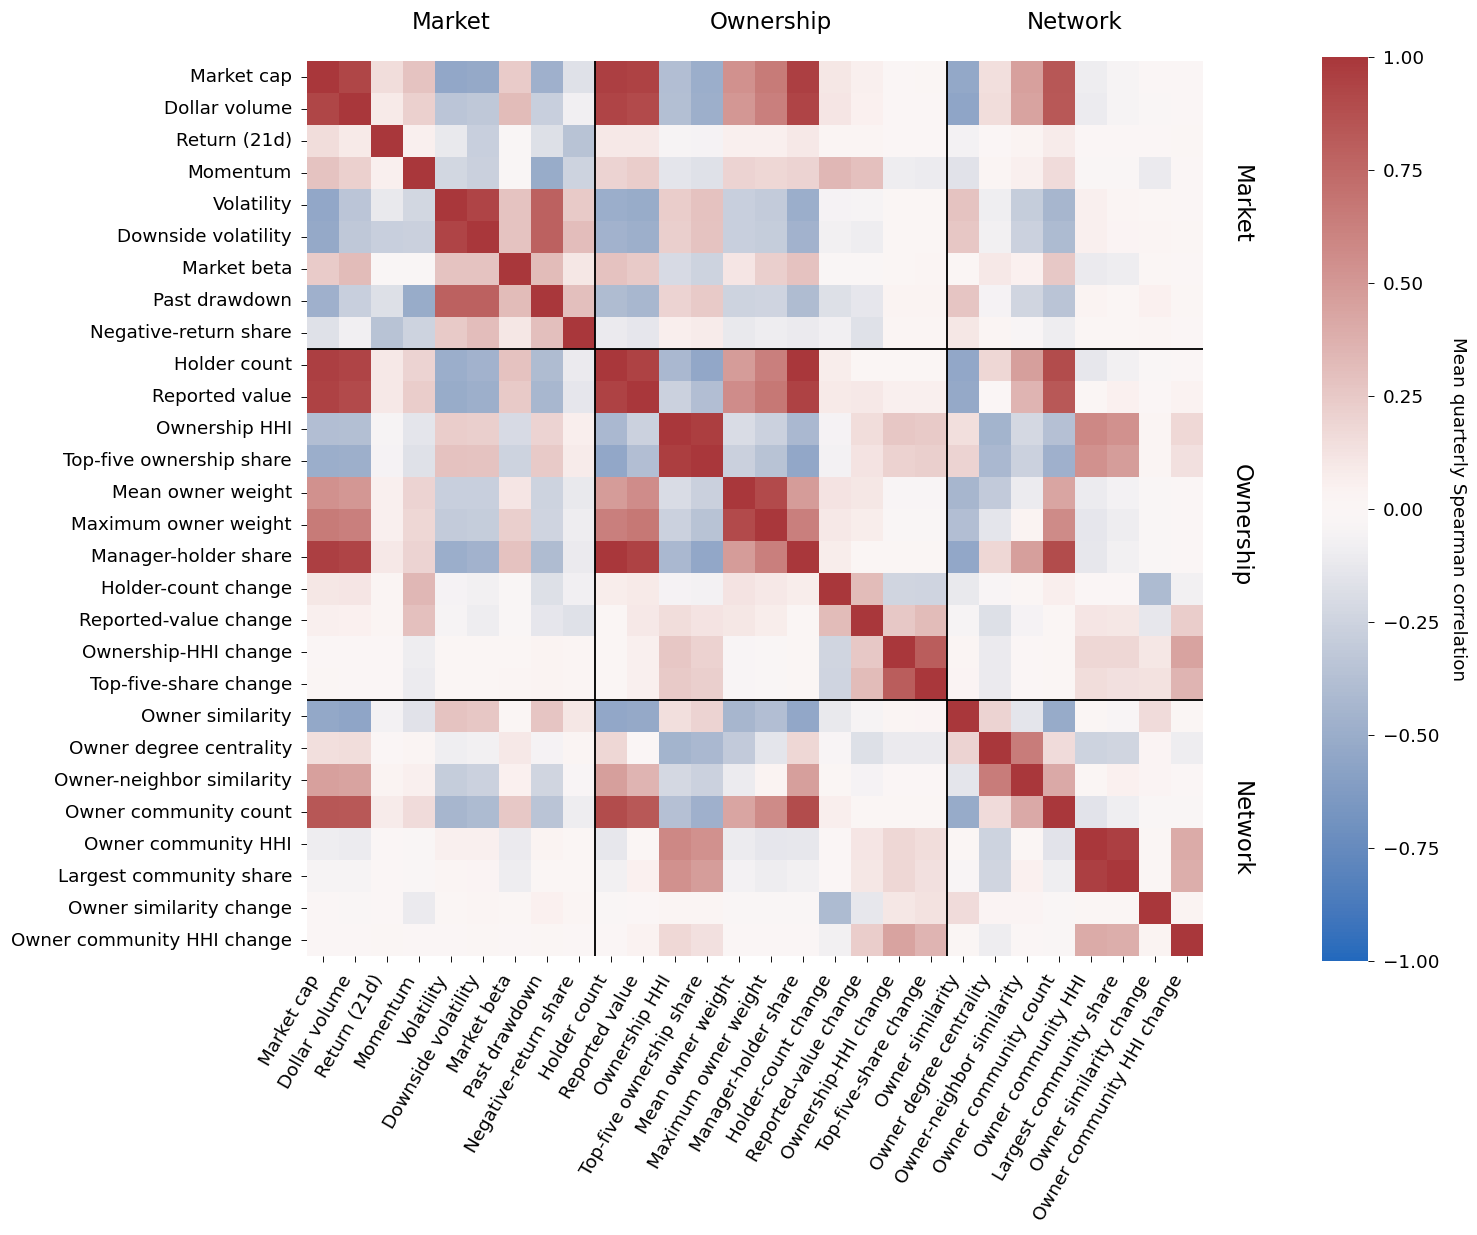

In [6]:
all_features = [
    *market_features,
    *ownership_features,
    *network_features,
]
all_labels = {**traditional_labels, **network_labels}

quarterly_correlation_matrices = [
    quarter[all_features].corr(method="spearman")
    for _, quarter in training.groupby("report_period", sort=True)
]

mean_correlation_matrix = (
    pd.concat(
        quarterly_correlation_matrices,
        keys=range(len(quarterly_correlation_matrices)),
    )
    .groupby(level=1)
    .mean()
    .loc[all_features, all_features]
    .rename(index=all_labels, columns=all_labels)
)

market_end = len(market_features)
ownership_end = market_end + len(ownership_features)
feature_count = len(all_features)

feature_groups = [
    ("Market", 0, market_end),
    ("Ownership", market_end, ownership_end),
    ("Network", ownership_end, feature_count),
]

figure, axis = plt.subplots(figsize=(14, 12))

sns.heatmap(
    mean_correlation_matrix,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    cbar_kws={
        "label": "Mean quarterly Spearman correlation",
        "pad": 0.10,
        "shrink": 0.85,
    },
    ax=axis,
)

colorbar = axis.collections[0].colorbar
colorbar.set_label(
    "Mean quarterly Spearman correlation",
    rotation=270,
    labelpad=18,
)

# Separate the market, ownership, and network blocks.
for boundary in [market_end, ownership_end]:
    axis.axhline(boundary, color="black", linewidth=1.2)
    axis.axvline(boundary, color="black", linewidth=1.2)

axis.set_xlabel("")
axis.set_ylabel("")
axis.tick_params(axis="x", labelrotation=60)
axis.tick_params(axis="y", labelrotation=0)

for label in axis.get_xticklabels():
    label.set_horizontalalignment("right")

# Add feature-group headings above the columns.
for group, start, end in feature_groups:
    center = (start + end) / 2

    axis.text(
        center,
        1.03,
        group,
        transform=axis.get_xaxis_transform(),
        ha="center",
        va="bottom",
        clip_on=False,
    )

# Add feature-group headings to the right of the rows.
for group, start, end in feature_groups:
    center = (start + end) / 2

    axis.text(
        1.03,
        center,
        group,
        transform=axis.get_yaxis_transform(),
        ha="left",
        va="center",
        rotation=270,
        clip_on=False,
    )

apply_matplotlib_layout(figure)
figure.savefig(
    paths.figures / "04_03_all_feature_correlations.pdf"
)
plt.show()

In [7]:
feature_group_by_label = {
    **{
        traditional_labels[feature]: "Market"
        for feature in market_features
    },
    **{
        traditional_labels[feature]: "Ownership"
        for feature in ownership_features
    },
    **{
        network_labels[feature]: "Network"
        for feature in network_features
    },
}

upper_triangle = np.triu(
    np.ones(mean_correlation_matrix.shape, dtype=bool),
    k=1,
)

strong_correlations = (
    mean_correlation_matrix.where(upper_triangle)
    .stack()
    .rename("spearman_correlation")
    .reset_index()
    .rename(
        columns={
            "level_0": "feature_1",
            "level_1": "feature_2",
        }
    )
)

strong_correlations["absolute_correlation"] = (
    strong_correlations["spearman_correlation"].abs()
)

strong_correlations = (
    strong_correlations.loc[
        strong_correlations["absolute_correlation"].ge(0.70)
    ]
    .assign(
        group_1=lambda frame: frame["feature_1"].map(
            feature_group_by_label
        ),
        group_2=lambda frame: frame["feature_2"].map(
            feature_group_by_label
        ),
    )
    .sort_values("absolute_correlation", ascending=False)
    .reset_index(drop=True)
)

display(
    strong_correlations[
        [
            "group_1",
            "feature_1",
            "group_2",
            "feature_2",
            "spearman_correlation",
        ]
    ].style.format(
        {"spearman_correlation": "{:.3f}"}
    )
)

,group_1,feature_1,group_2,feature_2,spearman_correlation
0,Ownership,Holder count,Ownership,Manager-holder share,1.000
1,Ownership,Ownership HHI,Ownership,Top-five ownership share,0.963
2,Network,Owner community HHI,Network,Largest community share,0.958
3,Market,Market cap,Ownership,Holder count,0.954
4,Market,Market cap,Ownership,Manager-holder share,0.954
5,Market,Market cap,Ownership,Reported value,0.943
6,Ownership,Reported value,Ownership,Manager-holder share,0.938
7,Ownership,Holder count,Ownership,Reported value,0.938
8,Market,Dollar volume,Ownership,Holder count,0.937
9,Market,Dollar volume,Ownership,Manager-holder share,0.937


## 6. Interpretation

- **Script 18 preserves the original modeling sample exactly.** The combined file contains the same 184,018 rows, original columns, values, ordering, target, and train–validation–test assignments. It adds only the six retained network-rank columns and introduces no duplicate stock-quarter keys.
- **Every saved rank is correct.** Independent ranking of the raw network features over the complete quarterly security universe reproduces all saved values with a maximum absolute difference of zero. Static ranks are complete and bounded within `[0, 1]`.
- **Missingness remains limited to network changes.** Each of the two change ranks is missing for 3,832 observations, or 2.08% of the combined sample. This matches the unavailable raw changes exactly and is not caused by the merge or ranking operation.
- **Owner-community count overlaps substantially with traditional scale variables.** Its cross-sectional correlation is 0.890 with both institutional holder count and manager-holder share, 0.843 with market capitalization, 0.833 with dollar volume, and 0.830 with total reported institutional value. All five cross-block correlations above 0.75 involve this one network feature.
- **The other network constructs are more distinct.** Owner-community HHI correlates 0.583 with traditional ownership HHI, while largest-community share correlates 0.536 with traditional ownership HHI. Owner similarity has moderate negative correlations with size and ownership breadth, ranging from approximately -0.53 to -0.56.
- **Traditional risk variables have the strongest standalone target relationships.** Mean quarterly target correlations are 0.647 for total volatility, 0.646 for downside volatility, and 0.607 for past drawdown. Among network features, owner-community count reaches -0.295 and owner similarity reaches 0.211.

The joint modeling sample is therefore technically correct and suitable for Script 19. The correlation results show why univariate network associations are insufficient: owner-community count may partly proxy for firm and ownership scale, so genuine incremental network value must be judged by validation performance after the traditional predictors are already included.